## HW6
#### GUO TIANYUE

Refer to some ways of language grammar in ChatGpt.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Question 1
np.random.seed(42)  # For reproducibility
num_samples = 1000
x1 = np.random.uniform(0, 1, num_samples)
x2 = np.random.uniform(0, 1, num_samples)

# Generate y with noise
epsilon = np.random.normal(0, 0.1, num_samples)
y = x1**2 + x2**2 + epsilon

# Combine x1 and x2 into a feature matrix X
X = np.vstack((x1, x2)).T



In [8]:
# Question 2

# Initialize weights and biases
input_size = 2
hidden_size = 10
output_size = 1
learning_rate = 0.01
iterations = 1000

# Random initialization of weights and biases
np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros(hidden_size)
W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros(output_size)

# Define activation function and its derivative (ReLU)
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# Feedforward function
def feedforward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    return Z1, A1, Z2

# Backpropagation function
def backprop(X, y, Z1, A1, Z2, W1, W2, b1, b2, learning_rate):
    m = len(y)
    y = y.reshape(-1, 1)
    
    # Output layer gradients
    dZ2 = Z2 - y
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0) / m

    # Hidden layer gradients
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (X.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0) / m

    
    # Update weights and biases
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    return W1, b1, W2, b2

# Train the neural network
errors = []
for i in range(iterations):
    Z1, A1, Z2 = feedforward(X, W1, b1, W2, b2)
    error = np.mean((Z2 - y.reshape(-1, 1))**2)
    errors.append(error)
    W1, b1, W2, b2 = backprop(X, y, Z1, A1, Z2, W1, W2, b1, b2, learning_rate)


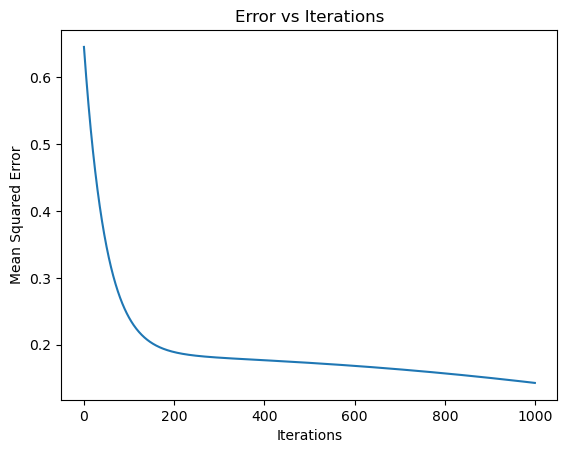

In [9]:
# Question 3
plt.plot(errors)
plt.title("Error vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error")
plt.show()


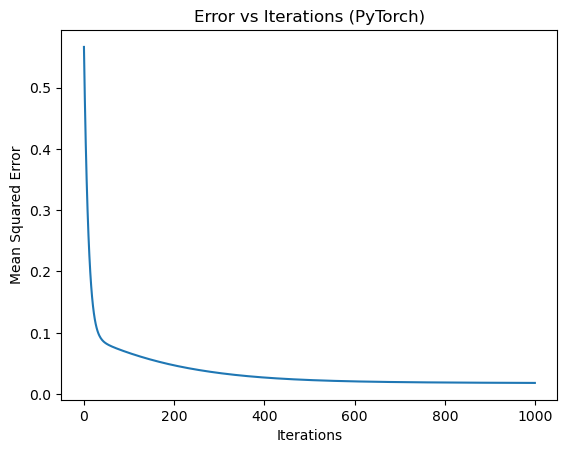

In [10]:
# Question 4
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.hidden = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.output = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return x

# Prepare data for PyTorch
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

# Model, loss function, and optimizer
model = NeuralNetwork()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# Train the model
torch_errors = []
for epoch in range(iterations):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    torch_errors.append(loss.item())
    loss.backward()
    optimizer.step()

# Visualization
plt.plot(torch_errors)
plt.title("Error vs Iterations (PyTorch)")
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error")
plt.show()
